In [1]:
import tensorflow as tf
tf.__version__

'2.15.0'

In [2]:
dataset_mnist = tf.keras.datasets.mnist
(img_train, label_train), (img_test, label_test) = dataset_mnist.load_data()

5


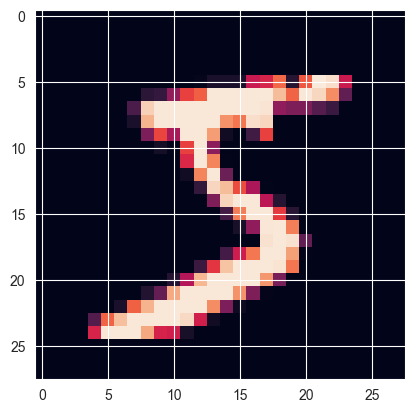

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(linewidth=200)
plt.imshow(img_train[0])
print(label_train[0])

In [4]:
img_train = img_train / 225.0
img_test = img_test / 225.0

In [5]:
img_train.shape

(60000, 28, 28)

In [6]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(img_train, label_train, epochs=5)


Epoch 1/5


1875/1875 [==============================] - 14s 6ms/step - loss: 0.2582 - accuracy: 0.9254
Epoch 2/5
1875/1875 [==============================] - 11s 6ms/step - loss: 0.1138 - accuracy: 0.9659
Epoch 3/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0779 - accuracy: 0.9768
Epoch 4/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0571 - accuracy: 0.9822
Epoch 5/5
1875/1875 [==============================] - 10s 6ms/step - loss: 0.0450 - accuracy: 0.9865


### Make model with TensorFlow Datasets
Previous we make model with tf.data.Datasets (API from tensorflow).
For now we use external library name is tensorflow_datasets or it can be called "TFDS"

In [7]:
import tensorflow_datasets as tfds

print(tfds.list_builders())
print(f"Total datasets: {len(tfds.list_builders())}")

['abstract_reasoning', 'accentdb', 'aeslc', 'aflw2k3d', 'ag_news_subset', 'ai2_arc', 'ai2_arc_with_ir', 'ai2dcaption', 'aloha_mobile', 'amazon_us_reviews', 'anli', 'answer_equivalence', 'arc', 'asqa', 'asset', 'assin2', 'asu_table_top_converted_externally_to_rlds', 'austin_buds_dataset_converted_externally_to_rlds', 'austin_sailor_dataset_converted_externally_to_rlds', 'austin_sirius_dataset_converted_externally_to_rlds', 'bair_robot_pushing_small', 'bc_z', 'bccd', 'beans', 'bee_dataset', 'beir', 'berkeley_autolab_ur5', 'berkeley_cable_routing', 'berkeley_fanuc_manipulation', 'berkeley_gnm_cory_hall', 'berkeley_gnm_recon', 'berkeley_gnm_sac_son', 'berkeley_mvp_converted_externally_to_rlds', 'berkeley_rpt_converted_externally_to_rlds', 'big_patent', 'bigearthnet', 'billsum', 'binarized_mnist', 'binary_alpha_digits', 'ble_wind_field', 'blimp', 'booksum', 'bool_q', 'bot_adversarial_dialogue', 'bridge', 'bridge_data_msr', 'bucc', 'c4', 'c4_wsrs', 'caltech101', 'caltech_birds2010', 'caltech

In [8]:
ds = tfds.load("mnist", split="train", shuffle_files=True)
assert isinstance(ds, tf.data.Dataset)

In [9]:
(train_img, train_label), (test_img, test_label) = tfds.as_numpy(
    tfds.load(
        "mnist",
        split=["train", "test"],
        batch_size=-1,
        as_supervised=True
    )
)

In [23]:
conv2d_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(68, (3,3), activation="relu",),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation="relu",),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

In [25]:
conv2d_model.compile(
    optimizer=tf.keras.optimizers.RMSprop(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [26]:
conv2d_model.fit(train_img, train_label, epochs=5, batch_size=50)

Epoch 1/5
1200/1200 [==============================] - 31s 24ms/step - loss: 0.3056 - accuracy: 0.9230
Epoch 2/5
1200/1200 [==============================] - 28s 23ms/step - loss: 0.0848 - accuracy: 0.9765
Epoch 3/5
1200/1200 [==============================] - 33s 27ms/step - loss: 0.0642 - accuracy: 0.9825
Epoch 4/5
1200/1200 [==============================] - 28s 24ms/step - loss: 0.0542 - accuracy: 0.9852
Epoch 5/5
1200/1200 [==============================] - 26s 22ms/step - loss: 0.0498 - accuracy: 0.9873


In [27]:
conv2d_model.evaluate(test_img, test_label, batch_size=1)

10000/10000 [==============================] - 49s 5ms/step - loss: 0.1048 - accuracy: 0.9769


[0.1047937348484993, 0.9768999814987183]

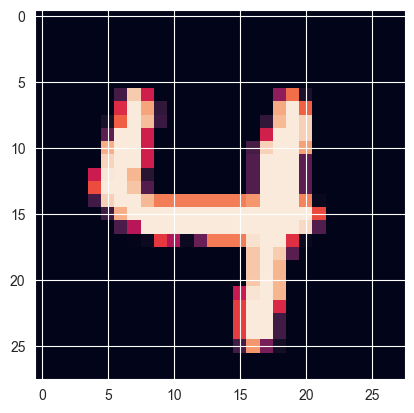

In [28]:
plt.imshow(test_img[2])

In [36]:
import numpy as np

pred = conv2d_model.predict(test_img[2].reshape(1,28,28,1))

np.argmax(pred)

1/1 [==============================] - 0s 141ms/step


4